In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/skin_disease_project"

CSV_PATH = f"{BASE_DIR}/fitzpatrick17k.csv"
IMAGE_DIR = f"{BASE_DIR}/images"
MODEL_DIR = f"{BASE_DIR}/models"
RESULTS_DIR = f"{BASE_DIR}/results"

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project setup complete.")

Project setup complete.


In [ ]:
import os

print(os.path.exists(CSV_PATH))
print(CSV_PATH)

True
/content/drive/MyDrive/skin_disease_project/fitzpatrick17k.csv


In [ ]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

print(df.shape)
df.head()

(16577, 9)


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [ ]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (16577, 9)

Columns:
['md5hash', 'fitzpatrick_scale', 'fitzpatrick_centaur', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum']


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [ ]:
# Count images for each disease
class_counts = df["label"].value_counts()

# Check different minimum-image thresholds
thresholds = [25, 50, 100, 150, 200, 300, 500]

for threshold in thresholds:
    count = (class_counts >= threshold).sum()
    print(f"Classes with >= {threshold} images: {count}")

Classes with >= 25 images: 114
Classes with >= 50 images: 114
Classes with >= 100 images: 60
Classes with >= 150 images: 37
Classes with >= 200 images: 20
Classes with >= 300 images: 13
Classes with >= 500 images: 2


In [ ]:
print(class_counts)

label
psoriasis                      653
squamous cell carcinoma        581
lichen planus                  491
basal cell carcinoma           468
allergic contact dermatitis    430
                              ... 
paronychia                      59
erythema elevatum diutinum      55
pustular psoriasis              53
pilomatricoma                   53
xanthomas                       53
Name: count, Length: 114, dtype: int64


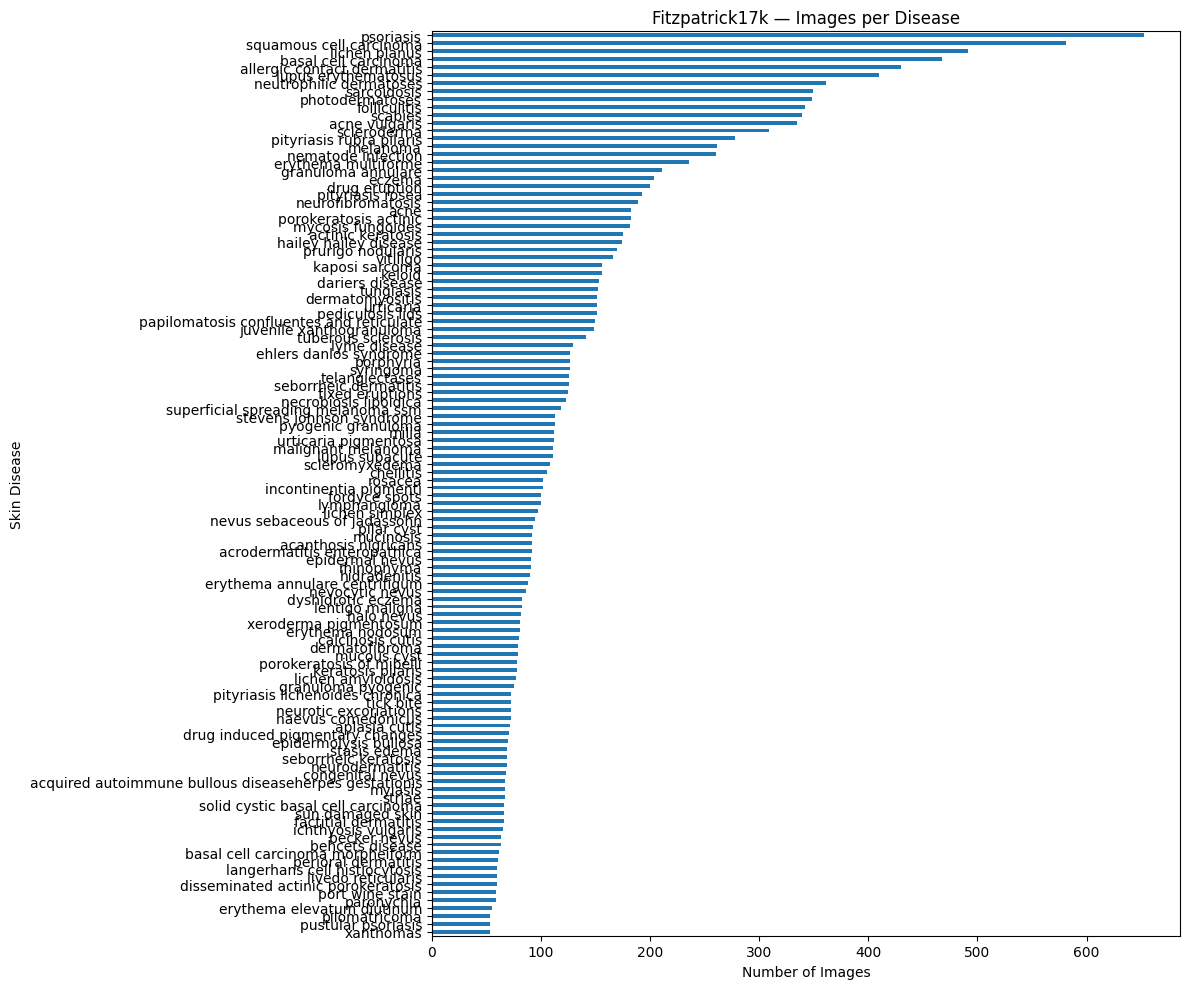

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

class_counts.sort_values().plot(kind="barh")

plt.xlabel("Number of Images")
plt.ylabel("Skin Disease")
plt.title("Fitzpatrick17k — Images per Disease")

plt.tight_layout()
plt.show()

In [ ]:
print("Fitzpatrick skin type distribution:")

display(
    df["fitzpatrick_scale"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("image_count")
)

Fitzpatrick skin type distribution:


,image_count
fitzpatrick_scale,
-1,565
1,2947
2,4808
3,3308
4,2781
5,1533
6,635


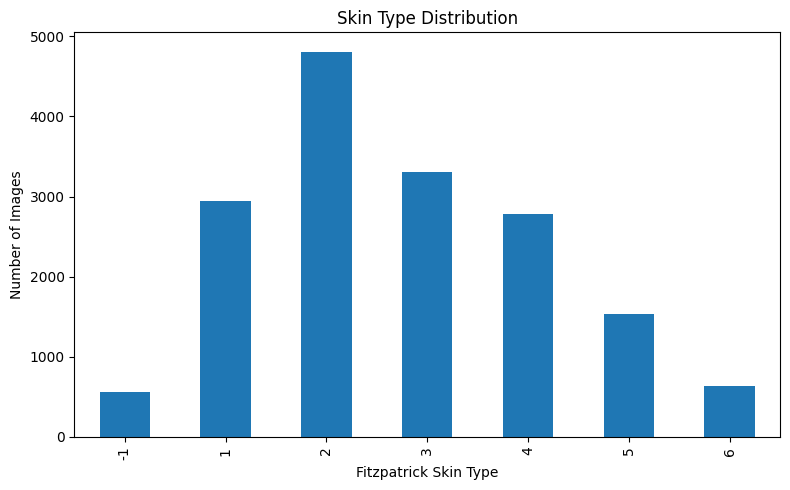

In [ ]:
plt.figure(figsize=(8, 5))

df["fitzpatrick_scale"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Fitzpatrick Skin Type")
plt.ylabel("Number of Images")
plt.title("Skin Type Distribution")

plt.tight_layout()
plt.show()

In [ ]:
print("Total images:", len(df))
print("Missing URLs:", df["url"].isna().sum())
print("Available URLs:", df["url"].notna().sum())

Total images: 16577
Missing URLs: 41
Available URLs: 16536


In [ ]:
top_13 = class_counts[class_counts >= 300].sort_values(
    ascending=False
)

print("Selected classes:")
display(top_13.to_frame("image_count"))

Selected classes:


,image_count
label,
psoriasis,653
squamous cell carcinoma,581
lichen planus,491
basal cell carcinoma,468
allergic contact dermatitis,430
lupus erythematosus,410
neutrophilic dermatoses,361
sarcoidosis,349
photodermatoses,348


In [ ]:
# Our selected 13 diseases
selected_classes = top_13.index.tolist()

selected_df = df[df["label"].isin(selected_classes)].copy()

# Check URL availability per class
url_stats = (
    selected_df
    .groupby("label")
    .agg(
        total_images=("label", "size"),
        valid_urls=("url", lambda x: x.notna().sum()),
        missing_urls=("url", lambda x: x.isna().sum())
    )
    .sort_values("total_images", ascending=False)
)

display(url_stats)


,total_images,valid_urls,missing_urls
label,,,
psoriasis,653,653,0
squamous cell carcinoma,581,581,0
lichen planus,491,491,0
basal cell carcinoma,468,468,0
allergic contact dermatitis,430,430,0
lupus erythematosus,410,410,0
neutrophilic dermatoses,361,361,0
sarcoidosis,349,349,0
photodermatoses,348,348,0


In [ ]:
import os
import re
import requests
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# Selected classes

selected_classes = top_13.index.tolist()

# Filter dataset
selected_df = df[df["label"].isin(selected_classes)].copy()

# Create image directories

for label in selected_classes:
    folder_name = re.sub(
        r"[^a-zA-Z0-9]+",
        "_",
        label
    ).strip("_").lower()

    os.makedirs(
        os.path.join(IMAGE_DIR, folder_name),
        exist_ok=True
    )

print("Image directories created.")

Image directories created.


In [ ]:
test_df = selected_df.head(10)

for _, row in test_df.iterrows():
    print(row["label"])
    print(row["url"])
    print()

photodermatoses
https://www.dermaamin.com/site/images/clinical-pic/p/photosensitivity/photosensitivity18.jpg

psoriasis
https://www.dermaamin.com/site/images/clinical-pic/p/psoriasis/psoriasis38.jpg

psoriasis
https://www.dermaamin.com/site/images/clinical-pic/p/psoriasis-scalp/psoriasis-scalp20.jpg

neutrophilic dermatoses
https://www.dermaamin.com/site/images/clinical-pic/s/sweet-syndrome/sweet-syndrome98.jpg

allergic contact dermatitis
https://www.dermaamin.com/site/images/clinical-pic/a/allergic_contact_dermatitis/allergic_contact_dermatitis114.jpg

neutrophilic dermatoses
https://www.dermaamin.com/site/images/clinical-pic/s/sweet-syndrome/sweet-syndrome50.jpg

acne vulgaris
https://www.dermaamin.com/site/images/clinical-pic/a/acne_vulgaris/acne_vulgaris150.jpg

sarcoidosis
https://www.dermaamin.com/site/images/clinical-pic/s/sarcoidosis-of-the-skin-plaque-form/sarcoidosis-of-the-skin-plaque-form15.jpg

scleroderma
https://www.dermaamin.com/site/images/clinical-pic/L/localized-scl

In [ ]:
import requests
from PIL import Image
from io import BytesIO

In [ ]:
import requests

try:
    response = requests.get(
        "https://www.google.com",
        timeout=10
    )

    print("Internet:", response.status_code)

except Exception as e:
    print("Internet connection failed:")
    print(e)

Internet: 200


In [ ]:
ZIP_PATH = "/content/drive/MyDrive/skin_disease_project/Fitzpatrick17k_CategorizedAbbrvs.zip"

print("ZIP exists:", os.path.exists(ZIP_PATH))

ZIP exists: True


In [ ]:
import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    files = z.namelist()

print("Total entries:", len(files))

print("\nFirst 30 entries:")
for file in files[:30]:
    print(file)

Total entries: 16692

First 30 entries:
Categorized_AbbrvName/
Categorized_AbbrvName/ac-au-bu-di-ge_67/
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_0_7632dbe0.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_13_0d8a8465.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_15_11a121c6.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_18_b2b7c4f8.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_19_d56176c7.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_21_2b2e5e50.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_26_4d41674b.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_27_ec8e57d5.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_28_ef9d5d96.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_31_75a4dac1.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_38_ddd82dcd.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_39_a942cdf5.jpg
Categoriz

In [ ]:
import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    folders = sorted({
        "/".join(f.split("/")[:2])
        for f in z.namelist()
        if f.lower().endswith(".jpg")
    })

print("Number of image folders:", len(folders))

for folder in folders:
    print(folder)

Number of image folders: 114
Categorized_AbbrvName/ac-au-bu-di-ge_67
Categorized_AbbrvName/ac-en_92
Categorized_AbbrvName/ac-ke_175
Categorized_AbbrvName/ac-ni_92
Categorized_AbbrvName/ac-vu_335
Categorized_AbbrvName/ac_183
Categorized_AbbrvName/al-co-de_430
Categorized_AbbrvName/ap-cu_72
Categorized_AbbrvName/ba-ce-ca-mo_62
Categorized_AbbrvName/ba-ce-ca_468
Categorized_AbbrvName/be-di_63
Categorized_AbbrvName/be-ne_63
Categorized_AbbrvName/ca-cu_80
Categorized_AbbrvName/ch_106
Categorized_AbbrvName/co-ne_68
Categorized_AbbrvName/da-di_153
Categorized_AbbrvName/defi_79
Categorized_AbbrvName/demy_151
Categorized_AbbrvName/di-ac-po_60
Categorized_AbbrvName/dr-er_200
Categorized_AbbrvName/dr-in-pi-ch_71
Categorized_AbbrvName/dy-ec_83
Categorized_AbbrvName/ec_204
Categorized_AbbrvName/eh-da-sy_127
Categorized_AbbrvName/ep-bu_70
Categorized_AbbrvName/ep-ne_91
Categorized_AbbrvName/er-an-ce_88
Categorized_AbbrvName/er-el-di_55
Categorized_AbbrvName/er-mu_236
Categorized_AbbrvName/er-no_81
C

In [ ]:
import re

# Get a few image filenames from the ZIP
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    image_files = [
        f for f in z.namelist()
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

print("Number of images:", len(image_files))

print("\nSample ZIP filenames:")
for f in image_files[:10]:
    print(f)

print("\nSample CSV hashes:")
print(df["md5hash"].head(10).tolist())

Number of images: 16577

Sample ZIP filenames:
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_0_7632dbe0.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_13_0d8a8465.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_15_11a121c6.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_18_b2b7c4f8.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_19_d56176c7.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_21_2b2e5e50.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_26_4d41674b.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_27_ec8e57d5.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_28_ef9d5d96.jpg
Categorized_AbbrvName/ac-au-bu-di-ge_67/ac-au-bu-di-ge_f1_31_75a4dac1.jpg

Sample CSV hashes:
['5e82a45bc5d78bd24ae9202d194423f8', 'fa2911a9b13b6f8af79cb700937cc14f', 'd2bac3c9e4499032ca8e9b07c7d3bc40', '0a94359e7eaacd7178e06b2823777789', 'a39ec3b1f22c08a421fa20535e037bba', '45f7fe0e1021

In [ ]:
import zipfile
import os
import re
import pandas as pd

# Read all image paths from ZIP
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    image_files = [
        f for f in z.namelist()
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

print("Images in ZIP:", len(image_files))

# Create lookup sets from CSV hashes
csv_hashes = set(df["md5hash"].astype(str).str.lower())

# Extract the final 8-character part from each ZIP filename
zip_suffixes = {}

for path in image_files:
    filename = os.path.basename(path)

    # Example:
    # ac-au-bu-di-ge_f1_0_7632dbe0.jpg
    #                         ^^^^^^^^
    match = re.search(r"_([a-fA-F0-9]{8})\.(?:jpg|jpeg|png)$", filename)

    if match:
        suffix = match.group(1).lower()
        zip_suffixes[suffix] = path

print("ZIP hashes found:", len(zip_suffixes))

# Check how many CSV MD5 hashes start/end with the ZIP suffix
matches_first8 = 0
matches_last8 = 0

for h in csv_hashes:
    if h[:8] in zip_suffixes:
        matches_first8 += 1

    if h[-8:] in zip_suffixes:
        matches_last8 += 1

print("CSV hashes matching FIRST 8 characters:", matches_first8)
print("CSV hashes matching LAST 8 characters:", matches_last8)

Images in ZIP: 16577
ZIP hashes found: 16577
CSV hashes matching FIRST 8 characters: 16577
CSV hashes matching LAST 8 characters: 0


In [ ]:
import os
import re
import zipfile
import shutil
from tqdm.auto import tqdm

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

EXTRACT_DIR = "/content/skin_dataset"

os.makedirs(EXTRACT_DIR, exist_ok=True)

# ---------------------------------------------------------
# Create mapping:
# first 8 chars of MD5 → ZIP image path
# ---------------------------------------------------------

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    image_files = [
        f for f in z.namelist()
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    hash_to_zip_path = {}

    for path in image_files:

        filename = os.path.basename(path)

        match = re.search(
            r"_([a-fA-F0-9]{8})\.(?:jpg|jpeg|png)$",
            filename
        )

        if match:
            hash8 = match.group(1).lower()
            hash_to_zip_path[hash8] = path

print("ZIP images mapped:", len(hash_to_zip_path))

# ---------------------------------------------------------
# Extract selected classes
# ---------------------------------------------------------

extracted = 0
missing = []

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    for _, row in tqdm(
        selected_df.iterrows(),
        total=len(selected_df),
        desc="Extracting selected images"
    ):

        md5 = str(row["md5hash"]).lower()

        hash8 = md5[:8]

        zip_path = hash_to_zip_path.get(hash8)

        if zip_path is None:
            missing.append({
                "md5hash": md5,
                "label": row["label"]
            })
            continue

        # Convert disease name into folder-safe name
        class_name = re.sub(
            r"[^a-zA-Z0-9]+",
            "_",
            row["label"]
        ).strip("_").lower()

        class_dir = os.path.join(
            EXTRACT_DIR,
            class_name
        )

        os.makedirs(class_dir, exist_ok=True)

        # Preserve original image extension
        extension = os.path.splitext(zip_path)[1]

        output_path = os.path.join(
            class_dir,
            f"{md5}{extension}"
        )

        # Don't extract again if already present
        if os.path.exists(output_path):
            extracted += 1
            continue

        with z.open(zip_path) as source:
            with open(output_path, "wb") as target:
                shutil.copyfileobj(source, target)

        extracted += 1

print("\n==============================")
print("EXTRACTION COMPLETE")
print("==============================")

print("Expected images :", len(selected_df))
print("Extracted       :", extracted)
print("Missing         :", len(missing))

if missing:
    print("\nMissing images:")
    print(missing[:10])

ZIP images mapped: 16577


Extracting selected images:   0%|          | 0/5416 [00:00<?, ?it/s]


EXTRACTION COMPLETE
Expected images : 5416
Extracted       : 5416
Missing         : 0


In [ ]:
from pathlib import Path
from PIL import Image

dataset_path = Path("/content/skin_dataset")

valid_images = 0
corrupt_images = []

for image_path in dataset_path.rglob("*"):
    if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        try:
            with Image.open(image_path) as img:
                img.verify()
            valid_images += 1

        except Exception as e:
            corrupt_images.append(str(image_path))

print("Valid images:", valid_images)
print("Corrupt images:", len(corrupt_images))

if corrupt_images:
    print("\nFirst few corrupt images:")
    for path in corrupt_images[:10]:
        print(path)

Valid images: 5416
Corrupt images: 0


In [ ]:
class_counts_local = {}

for class_dir in dataset_path.iterdir():
    if class_dir.is_dir():
        count = len([
            f for f in class_dir.iterdir()
            if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        class_counts_local[class_dir.name] = count

class_counts_local

{'allergic_contact_dermatitis': 430,
 'folliculitis': 342,
 'sarcoidosis': 349,
 'scabies': 339,
 'neutrophilic_dermatoses': 361,
 'lichen_planus': 491,
 'psoriasis': 653,
 'basal_cell_carcinoma': 468,
 'squamous_cell_carcinoma': 581,
 'photodermatoses': 348,
 'scleroderma': 309,
 'acne_vulgaris': 335,
 'lupus_erythematosus': 410}

In [ ]:
import pandas as pd

local_counts = (
    pd.Series(class_counts_local)
    .sort_values(ascending=False)
    .to_frame("image_count")
)

display(local_counts)

,image_count
psoriasis,653
squamous_cell_carcinoma,581
lichen_planus,491
basal_cell_carcinoma,468
allergic_contact_dermatitis,430
lupus_erythematosus,410
neutrophilic_dermatoses,361
sarcoidosis,349
photodermatoses,348
folliculitis,342


In [ ]:
from pathlib import Path
import pandas as pd

dataset_path = Path("/content/skin_dataset")

image_records = []

for class_dir in dataset_path.iterdir():

    if not class_dir.is_dir():
        continue

    label = class_dir.name

    for image_path in class_dir.iterdir():

        if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:

            image_records.append({
                "image_path": str(image_path),
                "label": label
            })

image_df = pd.DataFrame(image_records)

print("Total images:", len(image_df))
print("Total classes:", image_df["label"].nunique())

display(image_df.head())

Total images: 5416
Total classes: 13


,image_path,label
0,/content/skin_dataset/allergic_contact_dermati...,allergic_contact_dermatitis
1,/content/skin_dataset/allergic_contact_dermati...,allergic_contact_dermatitis
2,/content/skin_dataset/allergic_contact_dermati...,allergic_contact_dermatitis
3,/content/skin_dataset/allergic_contact_dermati...,allergic_contact_dermatitis
4,/content/skin_dataset/allergic_contact_dermati...,allergic_contact_dermatitis


In [ ]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temporary
train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    stratify=image_df["label"],
    random_state=42
)

# Split temporary 50/50
# → 15% validation
# → 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3791
Validation: 812
Test: 813


In [ ]:
print("TRAIN")
display(train_df["label"].value_counts().sort_index())

print("\nVALIDATION")
display(val_df["label"].value_counts().sort_index())

print("\nTEST")
display(test_df["label"].value_counts().sort_index())

TRAIN


,count
label,
acne_vulgaris,234
allergic_contact_dermatitis,301
basal_cell_carcinoma,328
folliculitis,239
lichen_planus,344
lupus_erythematosus,287
neutrophilic_dermatoses,253
photodermatoses,244
psoriasis,457



VALIDATION


,count
label,
acne_vulgaris,51
allergic_contact_dermatitis,64
basal_cell_carcinoma,70
folliculitis,52
lichen_planus,73
lupus_erythematosus,61
neutrophilic_dermatoses,54
photodermatoses,52
psoriasis,98



TEST


,count
label,
acne_vulgaris,50
allergic_contact_dermatitis,65
basal_cell_carcinoma,70
folliculitis,51
lichen_planus,74
lupus_erythematosus,62
neutrophilic_dermatoses,54
photodermatoses,52
psoriasis,98


In [ ]:
import torch
import torchvision
import sklearn

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
GPU: Tesla T4


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class SkinDiseaseDataset(Dataset):

    def __init__(self, dataframe, transform=None, class_to_idx=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label = row["label"]

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert label → integer
        label = self.class_to_idx[label]

        return image, label

In [ ]:
classes = sorted(image_df["label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Classes:")

for idx, class_name in idx_to_class.items():
    print(idx, "→", class_name)

Classes:
0 → acne_vulgaris
1 → allergic_contact_dermatitis
2 → basal_cell_carcinoma
3 → folliculitis
4 → lichen_planus
5 → lupus_erythematosus
6 → neutrophilic_dermatoses
7 → photodermatoses
8 → psoriasis
9 → sarcoidosis
10 → scabies
11 → scleroderma
12 → squamous_cell_carcinoma


In [ ]:
train_dataset = SkinDiseaseDataset(
    train_df,
    transform=train_transform,
    class_to_idx=class_to_idx
)

val_dataset = SkinDiseaseDataset(
    val_df,
    transform=val_test_transform,
    class_to_idx=class_to_idx
)

test_dataset = SkinDiseaseDataset(
    test_df,
    transform=val_test_transform,
    class_to_idx=class_to_idx
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 3791
Validation: 812
Test: 813


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([ 0,  8, 11,  8,  3,  8,  5,  8, 12,  8])


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cuda


In [ ]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
num_classes = len(classes)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )
)

model = model.to(device)

print("Number of classes:", num_classes)
print(model.classifier)

Number of classes: 13
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=13, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [ ]:
NUM_EPOCHS = 10

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            f"{MODEL_DIR}/best_model.pth"
        )

        print("  → Best model saved!")

KeyboardInterrupt: 

In [ ]:
NUM_EPOCHS = 20
PATIENCE = 4

best_val_loss = float("inf")
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            model.state_dict(),
            f"{MODEL_DIR}/best_model.pth"
        )

    # Best validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            f"{MODEL_DIR}/best_accuracy_model.pth"
        )

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/20] | Train Loss: 0.7306 | Train Acc: 0.9591 | Val Loss: 1.5023 | Val Acc: 0.6502
Epoch [2/20] | Train Loss: 0.7235 | Train Acc: 0.9625 | Val Loss: 1.4942 | Val Acc: 0.6478
Epoch [3/20] | Train Loss: 0.7220 | Train Acc: 0.9623 | Val Loss: 1.4880 | Val Acc: 0.6527
Epoch [4/20] | Train Loss: 0.7148 | Train Acc: 0.9678 | Val Loss: 1.4809 | Val Acc: 0.6650
Epoch [5/20] | Train Loss: 0.7076 | Train Acc: 0.9660 | Val Loss: 1.4832 | Val Acc: 0.6650
Epoch [6/20] | Train Loss: 0.7060 | Train Acc: 0.9681 | Val Loss: 1.4719 | Val Acc: 0.6589
Epoch [7/20] | Train Loss: 0.7149 | Train Acc: 0.9618 | Val Loss: 1.4685 | Val Acc: 0.6773
Epoch [8/20] | Train Loss: 0.7084 | Train Acc: 0.9678 | Val Loss: 1.4761 | Val Acc: 0.6539
Epoch [9/20] | Train Loss: 0.7062 | Train Acc: 0.9673 | Val Loss: 1.4699 | Val Acc: 0.6589
Epoch [10/20] | Train Loss: 0.7009 | Train Acc: 0.9689 | Val Loss: 1.4856 | Val Acc: 0.6663
Epoch [11/20] | Train Loss: 0.6922 | Train Acc: 0.9726 | Val Loss: 1.4722 | Val Acc: 0.65

In [ ]:
torch.save(
    model.state_dict(),
    f"{MODEL_DIR}/final_model.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
print("Best Validation Accuracy:", max(val_accuracies))
print("Best Epoch:", val_accuracies.index(max(val_accuracies)) + 1)

Best Validation Accuracy: 0.6687192118226601
Best Epoch: 15


In [ ]:
# Load the best validation-accuracy model
model.load_state_dict(
    torch.load(
        f"{MODEL_DIR}/best_accuracy_model.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best-accuracy model loaded successfully!")

Best-accuracy model loaded successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
test_accuracy = accuracy_score(all_labels, all_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=classes,
        digits=4
    )
)

Test Accuracy: 0.6494
Test Accuracy: 64.94%

Classification Report:

                             precision    recall  f1-score   support

              acne_vulgaris     0.8627    0.8800    0.8713        50
allergic_contact_dermatitis     0.5000    0.4000    0.4444        65
       basal_cell_carcinoma     0.7101    0.7000    0.7050        70
               folliculitis     0.7273    0.7843    0.7547        51
              lichen_planus     0.7119    0.5676    0.6316        74
        lupus_erythematosus     0.5286    0.5968    0.5606        62
    neutrophilic_dermatoses     0.6774    0.7778    0.7241        54
            photodermatoses     0.5319    0.4808    0.5051        52
                  psoriasis     0.6514    0.7245    0.6860        98
                sarcoidosis     0.6000    0.4528    0.5161        53
                    scabies     0.5781    0.7255    0.6435        51
                scleroderma     0.5091    0.6087    0.5545        46
    squamous_cell_carcinoma     0

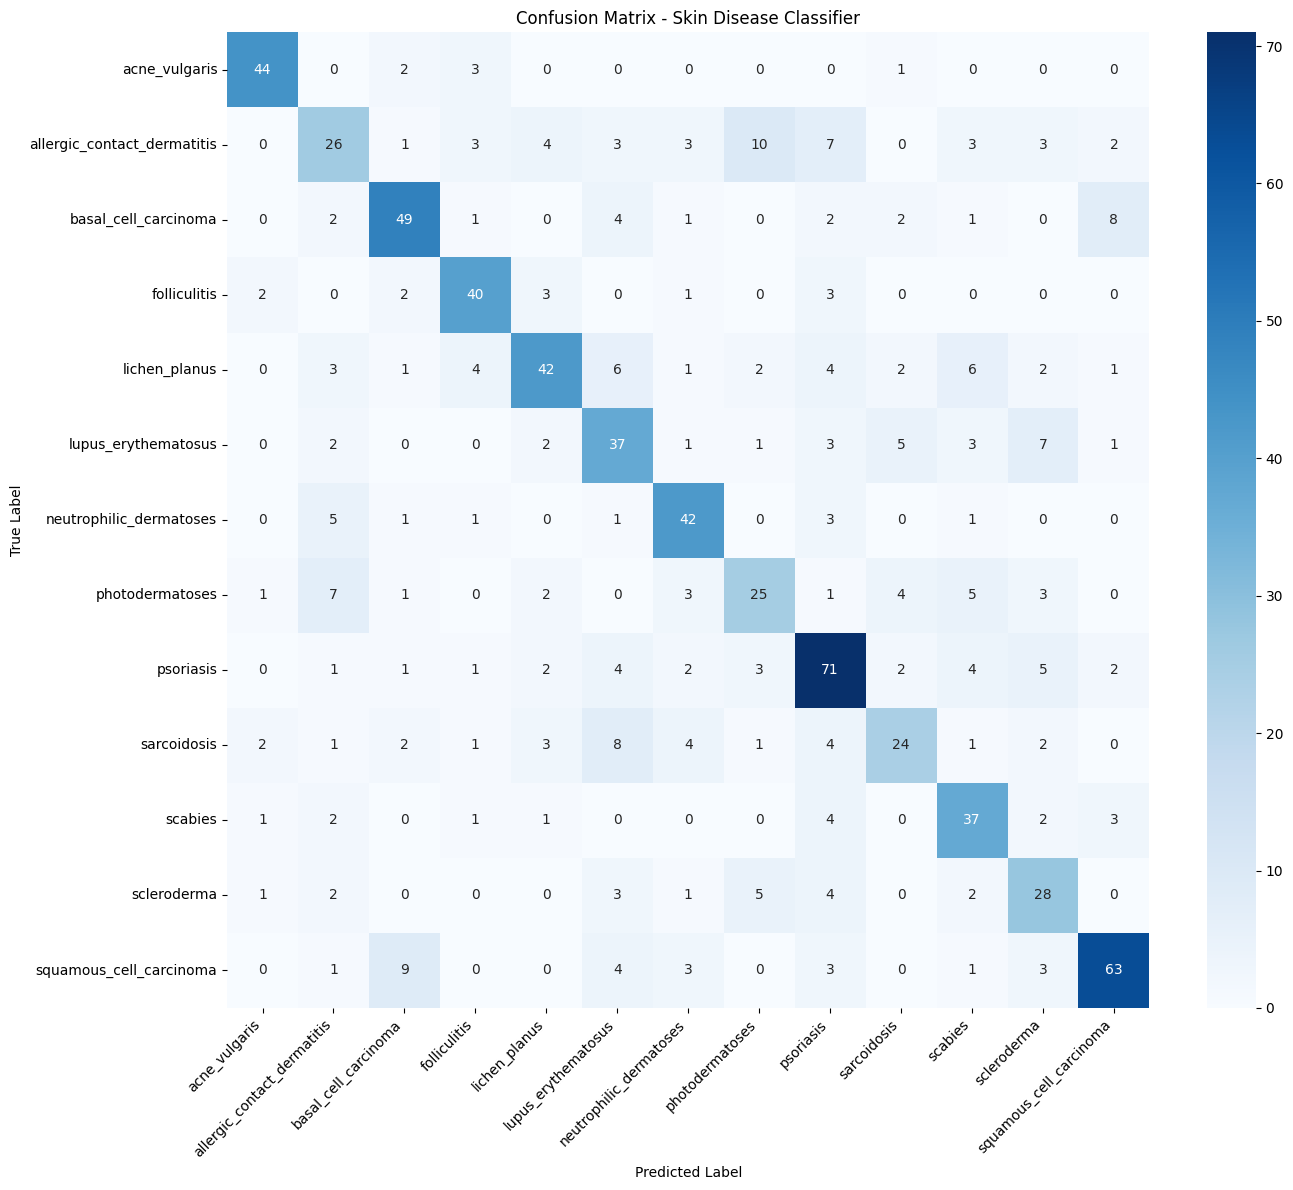

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Skin Disease Classifier")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()